In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Imposto il seed del generatore pseudo-casuale per garantire la riproducibilità del dataset
np.random.seed(42)

# Genero la feature indipendente X (dimensione 100x1).
# np.random.rand(100, 1) campiona da una distribuzione uniforme nell'intervallo [0, 1).
# Moltiplico per 10 per effettuare il riscalamento lineare nell'intervallo [0, 10).
X = 10 * np.random.rand(100, 1)

# Verifico la consistenza dimensionale del vettore colonna (Input Tensor shape)
print(f"Shape del vettore X: {X.shape}")

Shape del vettore X: (100, 1)


In [2]:
# Genero il rumore stocastico da sommare alla relazione lineare.
# np.random.randn(100, 1) campiona da una distribuzione normale standard (media=0, varianza=1).
# Moltiplico per 2.5 per riscalare la deviazione standard e aumentare la dispersione dei dati.
rumore = np.random.randn(100, 1) * 2.5

# Calcolo il vettore target y applicando la funzione lineare: y = w * X + b + rumore.
# Imposto i parametri reali ground-truth: peso (w) = 3.5 e bias (b) = 12.0.
y = 3.5 * X + 12.0 + rumore

# Verifico la consistenza dimensionale del vettore target
print(f"Shape del vettore y: {y.shape}")

Shape del vettore y: (100, 1)


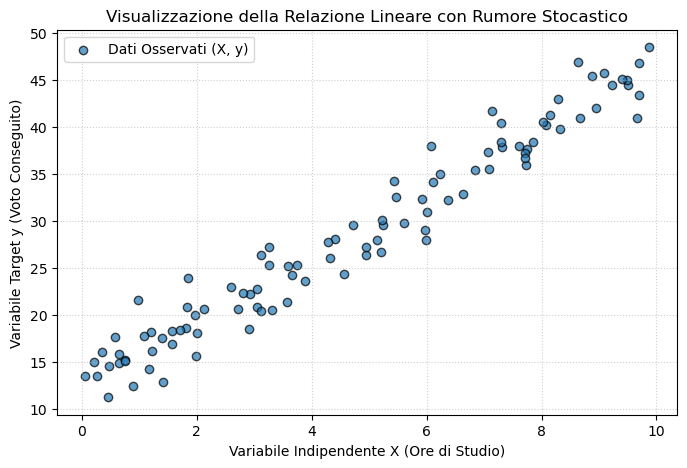

In [3]:
# Inizializzo la figura definendo le dimensioni in pollici (larghezza, altezza)
plt.figure(figsize=(8, 5))

# Genero un grafico a dispersione (scatter plot) per mappare la nuvola dei dati.
# alpha=0.7 imposta la trasparenza per identificare eventuali sovrapposizioni di punti.
# edgecolors='k' (black) evidenzia i contorni dei punti per una migliore leggibilità.
plt.scatter(X, y, color='#1f77b4', alpha=0.7, edgecolors='k', label='Dati Osservati (X, y)')

# Definisco le etichette degli assi e il titolo del grafico
plt.xlabel('Variabile Indipendente X (Ore di Studio)')
plt.ylabel('Variabile Target y (Voto Conseguito)')
plt.title('Visualizzazione della Relazione Lineare con Rumore Stocastico')

# Attivo la griglia di sfondo con stile puntinato per facilitare la lettura dei valori
plt.grid(True, linestyle=':', alpha=0.6)

# Mostro la legenda per identificare la tipologia di dato plottata
plt.legend()

# Rendering del grafico all'inte

In [4]:
# ==============================================================================
# NOTAZIONE CS229 (Andrew Ng, Lecture 2)
# ==============================================================================
# m = numero di esempi di training ; n = numero di feature.
# Aggiungo a ogni esempio la feature fittizia x0 = 1 (intercept term): cosi'
# l'ipotesi diventa h_theta(x) = theta^T x e theta0 fa da intercetta.
m = X.shape[0]   # numero di esempi (qui 100)
n = X.shape[1]   # numero di feature (qui 1)

# Design matrix: antepongo una colonna di 1 (la x0) alla matrice delle feature.
# X_b ha shape (m, n+1): prima colonna tutta 1, seconda colonna la X originale.
X_b = np.hstack([np.ones((m, 1)), X])
print(f"Shape della design matrix X_b (con colonna x0 = 1): {X_b.shape}")

# Vettore dei parametri theta inizializzato a zero (shape (n+1, 1)):
# theta[0] = theta0 (intercetta), theta[1] = theta1 (pendenza).
theta = np.zeros((n + 1, 1))

# Iperparametri. alpha = 0.02 col gradiente (1/m) equivale al passo usato prima.
alpha = 0.02         # learning rate
iterazioni = 400     # numero di passi di Batch Gradient Descent

print(f"Parametri iniziali theta (theta0, theta1):\n{theta.ravel()}")
print(f"Iperparametri -> alpha: {alpha} | iterazioni: {iterazioni} | m: {m} | n: {n}")

Shape della design matrix X_b (con colonna x0 = 1): (100, 2)
Parametri iniziali theta (theta0, theta1):
[0. 0.]
Iperparametri -> alpha: 0.02 | iterazioni: 400 | m: 100 | n: 1


In [5]:
def ipotesi(X_b, theta):
    """
    Ipotesi del modello (notazione CS229): h_theta(x) = theta^T x.
    In forma vettoriale su tutti gli esempi e' il prodotto matriciale X_b @ theta.
    X_b ha shape (m, n+1) e theta ha shape (n+1, 1) -> ritorna un vettore (m, 1).
    """
    return X_b @ theta


def costo_J(X_b, y, theta):
    """
    Funzione di costo dei minimi quadrati (CS229):
        J(theta) = (1 / 2m) * somma_i ( h_theta(x_i) - y_i )^2
    Il fattore 1/2 semplifica la derivata; 1/m media sul numero di esempi cosi'
    il learning rate alpha non dipende dalla taglia del dataset.
    (Ng alla lavagna scrive (1/2)*somma, senza 1/m: e' solo un fattore di scala.)
    """
    errori = ipotesi(X_b, theta) - y
    return (1 / (2 * m)) * np.sum(errori ** 2)


# Costo iniziale a theta = 0, prima dell'addestramento
print(f"Costo iniziale J(theta) con theta = 0: {costo_J(X_b, y, theta):.4f}")

Costo iniziale J(theta) con theta = 0: 457.5222


In [6]:
# Lista per tracciare l'andamento del costo J(theta) e monitorare la convergenza
storia_costo = []

print("Inizio l'addestramento (Batch Gradient Descent, notazione CS229)...")
print("-" * 62)

for iterazione in range(iterazioni):
    # 1. Ipotesi su TUTTI gli esempi contemporaneamente: h = X_b @ theta  (m x 1)
    h = ipotesi(X_b, theta)

    # 2. Gradiente di J(theta), derivato in Lecture 2:
    #    dJ/dtheta_j = (1/m) * somma_i ( h(x_i) - y_i ) * x_j_i
    #    In forma vettoriale calcolo tutte le derivate parziali insieme:
    gradiente = (1 / m) * (X_b.T @ (h - y))   # shape (n+1, 1)

    # 3. Aggiornamento simultaneo dei parametri (gradient descent):
    #    theta := theta - alpha * gradiente
    #    Equivale alla LMS di Ng: theta := theta + alpha * (y - h) * x
    theta = theta - alpha * gradiente

    # 4. Traccio il costo corrente
    costo_corrente = costo_J(X_b, y, theta)
    storia_costo.append(costo_corrente)

    if iterazione % 40 == 0 or iterazione == iterazioni - 1:
        print(f"Iter {iterazione:03d} -> J(theta): {costo_corrente:8.4f} | "
              f"theta0: {theta[0, 0]:.4f} | theta1: {theta[1, 0]:.4f}")

print("-" * 62)
print("Addestramento completato!")
print(f"Parametri finali -> theta0 (intercetta): {theta[0, 0]:.4f}, theta1 (pendenza): {theta[1, 0]:.4f}")
print(f"Valori reali (Ground Truth) -> theta0: 12.0000, theta1: 3.5000")

Inizio l'addestramento (Batch Gradient Descent, notazione CS229)...
--------------------------------------------------------------
Iter 000 -> J(theta):  80.8940 | theta0: 0.5691 | theta1: 3.2688
Iter 040 -> J(theta):  14.9195 | theta0: 3.1916 | theta1: 4.8215
Iter 080 -> J(theta):  10.4663 | theta0: 5.0560 | theta1: 4.5350
Iter 120 -> J(theta):   7.6125 | theta0: 6.5484 | theta1: 4.3056
Iter 160 -> J(theta):   5.7837 | theta0: 7.7431 | theta1: 4.1220
Iter 200 -> J(theta):   4.6117 | theta0: 8.6995 | theta1: 3.9750
Iter 240 -> J(theta):   3.8606 | theta0: 9.4652 | theta1: 3.8573
Iter 280 -> J(theta):   3.3793 | theta0: 10.0781 | theta1: 3.7631
Iter 320 -> J(theta):   3.0709 | theta0: 10.5687 | theta1: 3.6877
Iter 360 -> J(theta):   2.8732 | theta0: 10.9615 | theta1: 3.6273
Iter 399 -> J(theta):   2.7491 | theta0: 11.2689 | theta1: 3.5801
--------------------------------------------------------------
Addestramento completato!
Parametri finali -> theta0 (intercetta): 11.2689, theta1 (pen

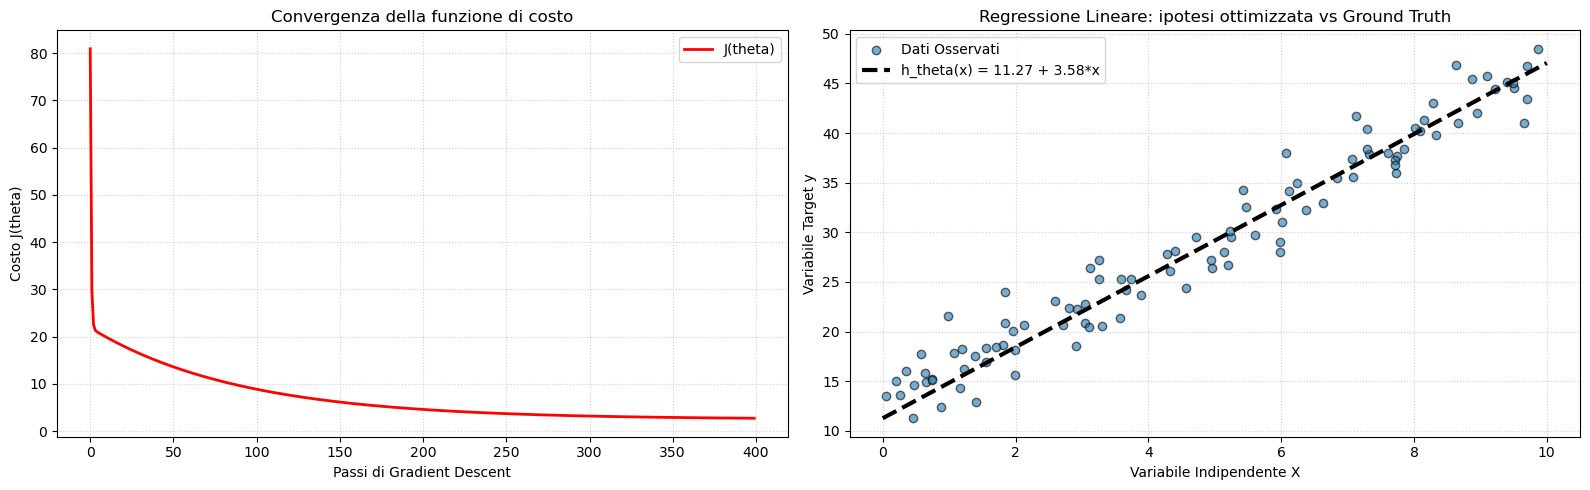

In [7]:
# Pannello con due sotto-grafici (1 riga, 2 colonne)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# GRAFICO 1: convergenza della funzione di costo J(theta)
ax1.plot(storia_costo, color='red', linewidth=2, label='J(theta)')
ax1.set_xlabel('Passi di Gradient Descent')
ax1.set_ylabel('Costo J(theta)')
ax1.set_title('Convergenza della funzione di costo')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend()

# GRAFICO 2: retta dell'ipotesi h_theta(x) sovrapposta ai dati
ax2.scatter(X, y, color='#1f77b4', alpha=0.6, edgecolors='k', label='Dati Osservati')

# Costruisco due punti estremi e aggiungo anche a loro la colonna x0 = 1
X_linea = np.array([[0.0], [10.0]])
X_linea_b = np.hstack([np.ones((2, 1)), X_linea])
y_linea = ipotesi(X_linea_b, theta)

ax2.plot(X_linea, y_linea, color='black', linestyle='--', linewidth=3,
         label=f'h_theta(x) = {theta[0, 0]:.2f} + {theta[1, 0]:.2f}*x')
ax2.set_xlabel('Variabile Indipendente X')
ax2.set_ylabel('Variabile Target y')
ax2.set_title('Regressione Lineare: ipotesi ottimizzata vs Ground Truth')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [8]:
# Predizioni finali del modello: h_theta(x) su tutti gli esempi
y_pred = ipotesi(X_b, theta)

# RMSE (radice dell'errore quadratico medio)
rmse = np.sqrt(np.mean((y_pred - y) ** 2))

# R^2 (coefficiente di determinazione)
somma_residui = np.sum((y - y_pred) ** 2)
somma_totale = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - somma_residui / somma_totale

print("METRICHE DI VALUTAZIONE FINALI:")
print("-" * 35)
print(f"RMSE: {rmse:.2f} punti di voto")
print(f"R^2 Score: {r2:.4f} ({r2 * 100:.2f}%)")

METRICHE DI VALUTAZIONE FINALI:
-----------------------------------
RMSE: 2.34 punti di voto
R^2 Score: 0.9479 (94.79%)
